In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scipi
import pandas as pd
import os as os
import seaborn as sns
import scipy.optimize 
import scipy.stats as st
import warnings
import statsmodels.api as sm
import matplotlib.ticker as mticker


from scipy.signal import savgol_filter
from scipy import stats
from scipy.stats import sem, wilcoxon,mannwhitneyu
from scipy.stats import ttest_ind
from scipy.stats import ttest_rel
from statsmodels.formula.api import ols
from matplotlib import rcParams


warnings.filterwarnings("ignore")

pathroot=os.getcwd()


saving_dir=os.path.join(pathroot,'figures')



print(pathroot)
os.chdir(pathroot)
cwd = os.getcwd()
print(cwd)

df=pd.read_csv(os.path.join(pathroot,'DataframeNCUZUpdated160724.csv'),delimiter=';')
LfpPop=np.load(os.path.join(pathroot,'LfpPop.npy'),allow_pickle=True)




mappingelectrode=[[11 ,4  ,8 ,13, 10,  6,  9 ,12], [14 , 1  ,2  ,3 ,15  ,5  ,0,  7], [30 ,22 ,28 ,29, 26, 27 ,24 ,31], [25 ,16, 20, 18, 23, 17 ,19 ,21]]

valid=np.ones((390,1))
df['Valid']=valid
DFDATA=df
mappingelectrode


columns = list(DFDATA.columns)
columns.remove('NewFileName')
columns.insert(0, 'NewFileName')
DFDATA = DFDATA[columns]

/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/Analyses_Zayan_et_al_NatureComm/LFP
/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/Analyses_Zayan_et_al_NatureComm/LFP


#

For svg texte

In [3]:
# Forcer l'utilisation du texte en tant que texte dans SVG
rcParams['svg.fonttype'] = 'path'
rcParams['font.family'] = 'DejaVu Sans'

# plt.rcParams.update({
#     'axes.labelsize': 16,   # Taille des labels des axes
#     'xtick.labelsize': 16,  # Taille des labels des ticks sur l'axe x
#     'ytick.labelsize': 16,  # Taille des labels des ticks sur l'axe y
#     'legend.fontsize': 10   # Taille de la police de la légende
# })

plt.rcParams.update({
    'axes.labelsize': 20,   # Taille des labels des axes
    'xtick.labelsize': 18,  # Taille des labels des ticks sur l'axe x
    'ytick.labelsize': 18,  # Taille des labels des ticks sur l'axe y
    'legend.fontsize': 12   # Taille de la police de la légende
})

#

In [4]:
DATA=DFDATA
DATA=DATA[DATA['ArrayId'].isin([8,9,10,12,13,14,15,16,17,22,24,29,31,32,33])]
DATA=DATA[(DATA['Stim'] == 'Tac') | (DATA['Stim'] == 'Thq')]

DATA


,NewFileName,ArrayId,Date,Stim,Therm,Side,Line,DayP,Anesthesie,CSF,Deep,FileName,CodeName,Valid
67,68,8,2024.01.30_M2,Thq,cool,Wcont,ML,P7,0,0,307,allego_5__uid0130-19-44-40,Thq_cool_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
68,69,8,2024.01.30_M2,Thq,hot,Wcont,ML,P7,0,0,307,allego_6__uid0130-19-56-12,Thq_hot_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
69,70,8,2024.01.30_M2,Thq,cool,Wcont,ML,P7,0,0,307,allego_7__uid0130-20-08-56,Thq_cool_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
70,71,8,2024.01.30_M2,Tac,none,Wcont,ML,P7,0,0,307,allego_8__uid0130-20-23-58,Tac_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
71,72,8,2024.01.30_M2,Tac,none,Wcont,ML,P7,0,0,307,allego_9__uid0130-20-34-38,Tac_Wcont_ML2_P7_M_3.7g_Buz32_Z307,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
347,348,33,2024.05.29,Thq,hot,Wcont,WT,P7,0,1,407,allego_6__uid0529-15-26-31,"Thq_hot_Wcont_WT_P7_F_3,9g_Buz32_Z407_ACSF37_T...",1.0
348,349,33,2024.05.29,Thq,cool,Wcont,WT,P7,0,1,407,allego_7__uid0529-15-39-59,"Thq_cool_Wcont_WT_P7_F_3,9g_Buz32_Z407_ACSF37_...",1.0
349,350,33,2024.05.29,Thq,cool,Wcont,WT,P7,0,1,407,allego_9__uid0529-15-52-58,"Thq_cool_Wcont_WT_P7_F_3,9g_Buz32_Z407_ACSF37_...",1.0
350,351,33,2024.05.29,Thq,cool,Wipsi,WT,P7,0,1,407,allego_10__uid0529-16-05-22,"Thq_cool_Wipsi_WT_P7_F_3,9g_Buz32_Z407_ACSF37_...",1.0


In [5]:
# compute AUC mean for all channel and all files !!!And generazte columns in Dataframe


from scipy import stats
from matplotlib import rcParams
import warnings 
warnings.filterwarnings("ignore")

colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'
DATAALL=[]
DATAALL=pd.DataFrame(columns=['NewFileName','Date','ArrayId','Line','DayP','Stim','Therm','Side','ch','Response','MeanAUCBas','MeanAUCStim','ContrastAUC'])

for newfilename in DATA['NewFileName'].values:

    dffile=DATA[DATA['NewFileName']==newfilename]

    fileid = DATA.index[DATA['NewFileName'] == newfilename].tolist()

    MeanAUCBasch=[]
    MeanAUCStimch=[]
    Responsech=[]
    Responsefile=[]
    ContrastAUC=[]

    lfp=LfpPop[fileid[0]]
    
    if lfp[0].shape[0]<30000:

        for ch in range(32):
    

            lfpch=lfp[0][ch].T


            SizeLfp=np.shape(lfpch)

            derivative=np.diff(lfpch,axis=0)

            AUC=np.trapz(np.abs(derivative), axis=1)

            AUC_filt=savgol_filter(AUC, 101, 3)

            if (dffile['Stim'] == 'Tac').any:
                analysis_window=2000
            elif (dffile['Stim'] == 'Thq').any:
                if (dffile['Therm'] == 'cool').any:
                    analysis_window=3900
                elif (dffile['Therm'] == 'hot').any:
                    analysis_window=2200
            
            MeanAUCBasch.append(np.mean(AUC_filt[0:analysis_window]))
            MeanAUCStimch.append(np.mean(AUC_filt[10000:analysis_window+10000]))

            ContrastAUC.append((np.mean(AUC_filt[10000:analysis_window+10000])-np.mean(AUC_filt[0:analysis_window]))/(np.mean(AUC_filt[10000:analysis_window+10000])+np.mean(AUC_filt[0:analysis_window])))

            t_statistic, p_value = stats.ttest_rel(AUC_filt[0:analysis_window],AUC_filt[10000:analysis_window+10000],alternative='less')

            if p_value<0.05:
                ResponseCh=1
            else:
                ResponseCh=0

            Responsefile.append(ResponseCh)
    
        filename=[newfilename]*32
        stim=dffile['Stim'].values[0]
        therm=dffile['Therm'].values[0]
        side=dffile['Side'].values[0]
        arrayid=dffile['ArrayId'].values[0]
        linemice=dffile['Line'].values[0]
        dayP=dffile['DayP'].values[0]
        Channel=np.arange(1,33)
        Date=dffile['Date'].values[0]


        DATAch=pd.DataFrame({'NewFileName':filename,'Date':Date,'ArrayId':arrayid,'Line':linemice,'DayP':dayP,'Stim':stim,'Therm':therm,'Side':side,'ch':Channel,'Response':Responsefile,'MeanAUCBas':MeanAUCBasch,'MeanAUCStim':MeanAUCStimch,'ContrastAUC':ContrastAUC})

        DATAALL=pd.concat([DATAALL,DATAch])     
          

DATACleaned=DATAALL.dropna()
DATACleaned


,NewFileName,Date,ArrayId,Line,DayP,Stim,Therm,Side,ch,Response,MeanAUCBas,MeanAUCStim,ContrastAUC
0,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,1,1,58.994228,64.869667,0.047435
1,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,2,1,60.306206,64.590797,0.034305
2,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,3,1,61.391262,65.734909,0.034168
3,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,4,1,63.264408,68.356682,0.038689
4,68,2024.01.30_M2,8,ML,P7,Thq,cool,Wcont,5,1,60.046593,66.200333,0.048744
...,...,...,...,...,...,...,...,...,...,...,...,...,...
27,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,28,0,55.796989,53.540123,-0.020641
28,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,29,0,46.809673,44.428875,-0.026094
29,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,30,0,46.038757,44.210789,-0.020255
30,352,2024.05.29,33,WT,P7,Thq,hot,Wipsi,31,0,48.013290,45.102352,-0.031262


#

<p align="center" style="color:orange; font-size: 2em;">FIGURE S6 : WT - Tactile Stim </p>
<hr>

#

## Figure S6D

FileNotFoundError: [Errno 2] Aucun fichier ou dossier de ce nom: '/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/Analyses_Zayan_et_al_NatureComm/LFP/figures/Fig_S6D_LFP.png'

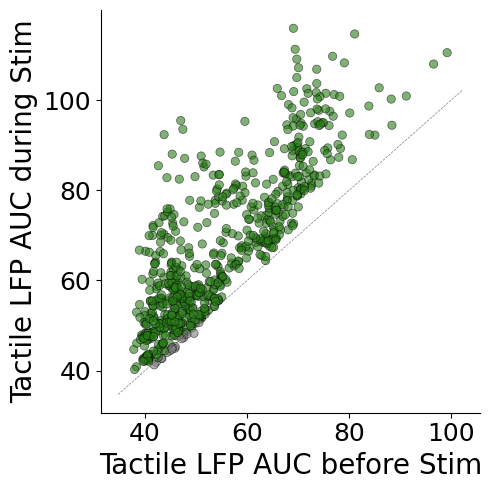

In [6]:
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'WT')]


DATAG=DATA

df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(5,5))

colors = {'#2a7e19', '#A8E5A0'}
colorborder='k'

sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,hue='Response',palette=['gray','#2a7e19'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('Tactile LFP AUC before Stim')
ax.set_ylabel('Tactile LFP AUC during Stim')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Fig_S6D_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(df['MeanAUCBas'],df['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()



#

## Figure S6E

FileNotFoundError: [Errno 2] Aucun fichier ou dossier de ce nom: '/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/Analyses_Zayan_et_al_NatureComm/LFP/figures/Fig_S6E_LFP.png'

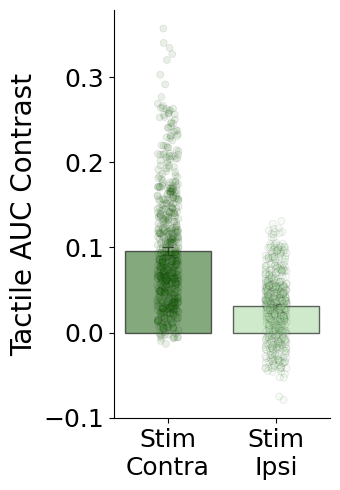

In [7]:
DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Line']== 'WT')]
DATA=DATA[['Date','Side','ContrastAUC']]


df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(3.5,5))

border_colors = 'k'
colors = ['#2a7e19','#A8E5A0']

sns.barplot(x='Side',y='ContrastAUC',data=DATA,ax=ax, palette=colors, capsize=0.1,
            err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors,zorder=3)
sns.stripplot(x='Side', y='ContrastAUC', data=DATA, ax=ax, palette=colors, alpha=0.1, edgecolor=border_colors,linewidth=0.5, jitter=True)

ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
ax.set_ylabel('Tactile AUC Contrast')
ax.set_xticklabels(['Stim\nContra','Stim\nIpsi'])

ax.set_xlabel('')
stat, p_value = mannwhitneyu(DATA[DATA['Side']=='Wcont']['ContrastAUC'], DATA[DATA['Side']=='Wipsi']['ContrastAUC'])


# # Fonction pour ajouter une barre de significativité
# def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.001, fontsize=18):
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     else:
#         return

#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# y_max=0.4
# if p_value < 0.05:
#     add_Wilcox_sig_bar(0, 1, y_max+0.01, p_value)


plt.tight_layout()

titrefig='Fig_S6E_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

p_value

#

## Figure S6J

FileNotFoundError: [Errno 2] Aucun fichier ou dossier de ce nom: '/media/nicolascatz/4d767acb-7d35-42a5-b630-86a61f8774d0/nicolascatz/DATA/Projets/Analyses_Zayan_et_al_NatureComm/LFP/figures/Fig_S6J_LFP.png'

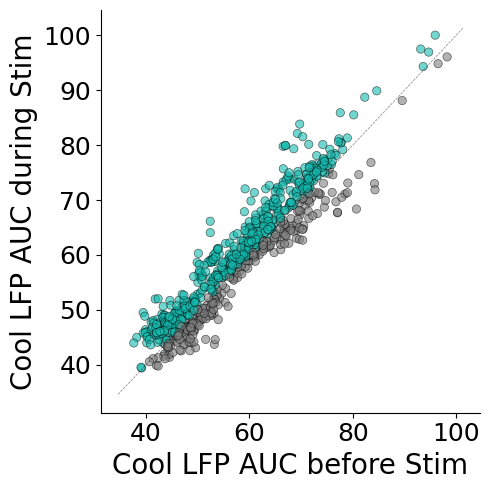

In [8]:
DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'cool') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'WT')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC','Response']]
DATAG=DATA

df = pd.DataFrame(DATAG)

fig,ax = plt.subplots(1,1, figsize=(5,5))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,hue='Response',palette=['gray','#13bbaf'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)


ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('Cool LFP AUC before Stim')
ax.set_ylabel('Cool LFP AUC during Stim')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Fig_S6J_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))

toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()

#

## Figure S6K

WilcoxonResult(statistic=97498.0, pvalue=0.27935555734962225)


True     344
False    296
Name: count, dtype: int64

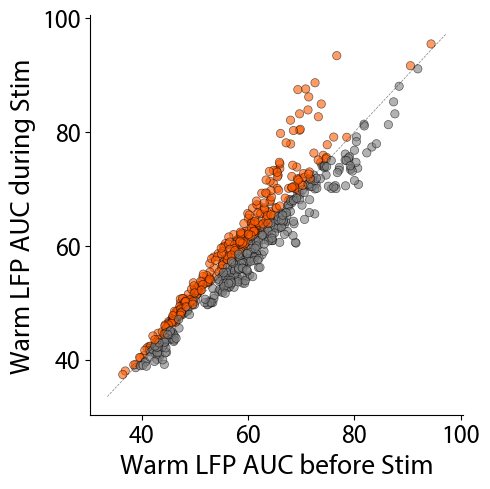

In [12]:
DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'hot') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'WT')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC','Response']]
DATAG=DATA

df = pd.DataFrame(DATAG)

fig,ax = plt.subplots(1,1, figsize=(5,5))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,hue='Response',palette=['gray','#ff5b00'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)

ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('Warm LFP AUC before Stim')
ax.set_ylabel('Warm LFP AUC during Stim')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Fig_S6K_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))

toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()

#

## Figure S6I

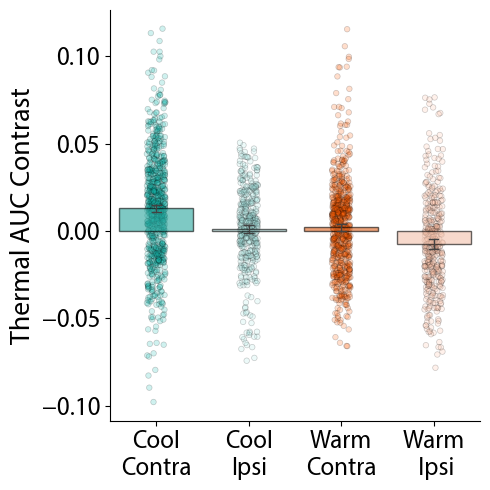

In [8]:
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq')]
DATA=DATA[(DATA['Line']== 'WT')]


df1=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wcont')]
df1['condition'] = df1['Therm'] + '_' + df1['Side']
df2=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wipsi')]
df2['condition'] = df2['Therm'] + '_' + df2['Side']
df3=DATA[(DATA['Therm'] == 'hot') & (DATA['Side'] == 'Wcont')]
df3['condition'] = df3['Therm'] + '_' + df3['Side']
df4=DATA[(DATA['Therm'] == 'hot') &(DATA['Side'] == 'Wipsi')]
df4['condition'] = df4['Therm'] + '_' + df4['Side']
df = pd.concat([df1, df2, df3, df4])

DF=df[['Date','condition','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DF1=DF[(DF['condition'] == 'cool_Wcont') ]
DF1.drop(columns=['condition'], inplace=True)
DF1['condition']='cool_Wcont'

DF2=DF[(DF['condition'] == 'cool_Wipsi') ]
DF2.drop(columns=['condition'], inplace=True)
DF2['condition']='cool_Wipsi'

DF3=DF[(DF['condition'] == 'hot_Wcont') ]
DF3.drop(columns=['condition'], inplace=True)
DF3['condition']='hot_Wcont'

DF4=DF[(DF['condition'] == 'hot_Wipsi') ]
DF4.drop(columns=['condition'], inplace=True)
DF4['condition']='hot_Wipsi'

DF=pd.concat([DF1,DF2,DF3,DF4])



colors = {'cool_Wcont': '#13bbaf', 'cool_Wipsi': '#A6E7E3', 
          'hot_Wcont': '#ff5b00', 'hot_Wipsi': '#FFBC9E'}
border_colors = 'k'




# Plot
fig,ax=plt.subplots(1,1, figsize=(5,5))
# Barplot avec erreur SEM
sns.barplot(ax=ax,x='condition', y='ContrastAUC',hue='condition' ,data=df, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)
ax.set_xticklabels(['Cool\nContra','Cool\nIpsi','Warm\nContra','Warm\n Ipsi'], multialignment='center')


x,x2,x3,x4=0,1,2,3

sns.stripplot(
    ax=ax,
    x='condition',
    y='ContrastAUC',
    data=DF,
    jitter=True,                   # pour étaler les points horizontalement
    dodge=False,                   # ne pas séparer par hue
    marker='o',
    edgecolor='k',
    linewidth=0.5,
    size=4,
    palette=colors,
    alpha=0.2,
    zorder=0
)

    
ax.set_ylabel('Thermal AUC Contrast')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_xlabel('')

titrefig='Fig_S6L_LFP'

plt.tight_layout()

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)


In [21]:
dfstats=[]
dfstats.append(DF1["ContrastAUC"].values)
dfstats.append(DF2["ContrastAUC"].values)
dfstats.append(DF3["ContrastAUC"].values)
dfstats.append(DF4["ContrastAUC"].values)

DataStats_figure_2J=dfstats

np.savez_compressed(os.path.join(saving_dir, 'Data_Stats_fig_S6J.npz'), *DataStats_figure_2J)



#

<p align="center" style="color:orange; font-size: 2em;">FIGURE S7 : ML2 - Tactile Stim </p>
<hr>

#

## Figure S7K

WilcoxonResult(statistic=241.0, pvalue=1.6055500518533133e-42)


True     239
False     17
Name: count, dtype: int64

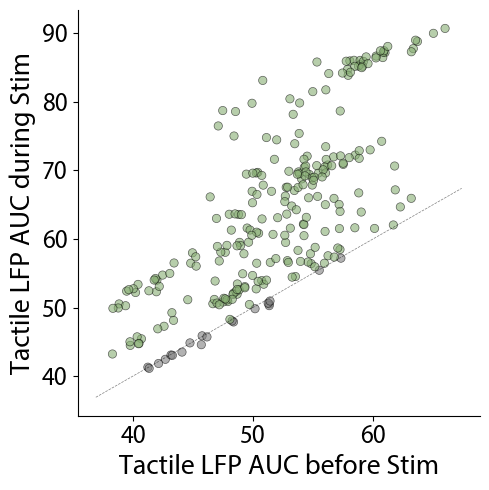

In [25]:
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Side'] == 'Wcont') ]
DATA=DATA[(DATA['Line']== 'ML')]


DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC','Response']]
DATAG=DATA

df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(5,5))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,hue='Response',palette=['gray','#87ae73'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('Tactile LFP AUC before Stim')
ax.set_ylabel('Tactile LFP AUC during Stim')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Fig_S7K_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))

toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()

#

## Figure S7L

0.00146905021327886

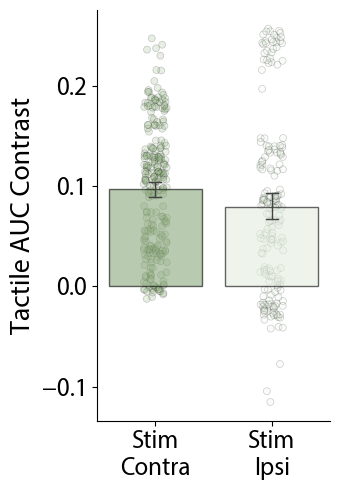

In [7]:
DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Line']== 'ML')]
DATA=DATA[['Date','Side','ContrastAUC']]


DATAcont=DATA[(DATA['Side']== 'Wcont')]
DATAipsi=DATA[(DATA['Side']== 'Wipsi')]

df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(3.5,5))

border_colors = 'k'
colors = ['#87ae73','#e2f0dc']

sns.barplot(x=df['Side'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)

sns.stripplot(x='Side', y='ContrastAUC', data=df, ax=ax, palette=colors, alpha=0.2, edgecolor=border_colors, linewidth=0.5, jitter=True, zorder=0)


ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Tactile AUC Contrast')
ax.set_xticklabels(['Stim\nContra','Stim\nIpsi'])
ax.set_xlabel('')

stat, p_value = mannwhitneyu(df[df['Side']=='Wcont']['ContrastAUC'], df[df['Side']=='Wipsi']['ContrastAUC'])


# # Fonction pour ajouter une barre de significativité
# def add_Wilcox_sig_bar(x1, x2, y, p_val, height_offset=0.001, fontsize=18):
#     if p_val < 0.001:
#         significance = "***"
#     elif p_val < 0.01:
#         significance = "**"
#     elif p_val < 0.05:
#         significance = "*"
#     else:
#         return

#     plt.plot([x1, x1, x2, x2], [y, y + height_offset, y + height_offset, y], lw=1, color='black')
#     plt.text((x1 + x2) * 0.5, y , significance, ha='center', va='bottom', color='black', fontsize=fontsize)

# y_max=0.3
# if p_value < 0.05:
#     add_Wilcox_sig_bar(0, 1, y_max+0.01, p_value)

plt.tight_layout()

titrefig='Fig_S7L_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)


p_value

#

<p align="center" style="color:orange; font-size: 2em;">FIGURE S8 : ML2 - Thermal Stim </p>
<hr>

#

## Figure S8P

WilcoxonResult(statistic=22690.0, pvalue=1.2854759437614474e-51)


True     473
False    103
Name: count, dtype: int64

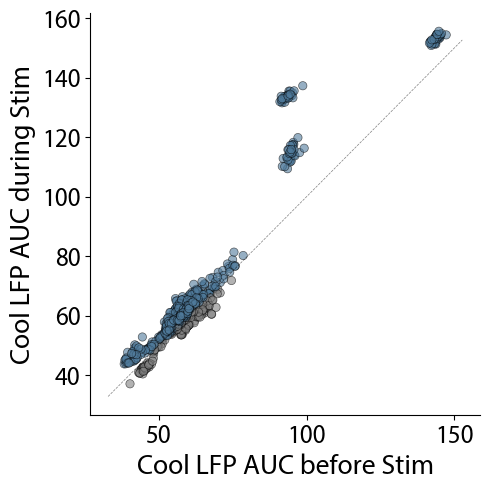

In [33]:
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'cool') ]
DATA=DATA[(DATA['Line']== 'ML')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC','Response']]
DATAG=DATA
df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(5,5))
sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,hue='Response',palette=['gray','#507b9c'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('Cool LFP AUC before Stim')
ax.set_ylabel('Cool LFP AUC during Stim')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Fig_S8P_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)



wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()

#

## Figure S8Q

WilcoxonResult(statistic=45616.0, pvalue=6.865902120819501e-05)
63.133003 60.8008


False    281
True     199
Name: count, dtype: int64

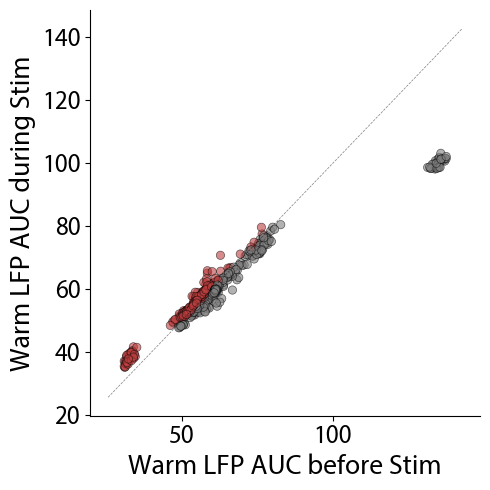

In [ ]:

DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Therm'] == 'hot') ]
DATA=DATA[(DATA['Line']== 'ML')]

DATA=DATA[['Date','MeanAUCBas','MeanAUCStim','ContrastAUC', 'Response']]
# DATAG=DATA.groupby(['Date']).mean()
DATAG=DATA

df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(5,5))

sns.scatterplot(x='MeanAUCBas',y='MeanAUCStim', data=df,hue='Response',palette=['gray','#bb3f3f'],edgecolor=colorborder, alpha=0.6,ax=ax,legend=False)
ax.plot(ax.get_xlim(), ax.get_xlim(), c='k',ls='--' ,linewidth=0.5, alpha=0.5)
ax.set_xlabel('Warm LFP AUC before Stim')
ax.set_ylabel('Warm LFP AUC during Stim')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()

titrefig='Fig_S8Q_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim'])

print(wilcoxon(DATAG['MeanAUCBas'],DATAG['MeanAUCStim']))
print(DATAG['MeanAUCBas'].mean(), DATAG['MeanAUCStim'].mean())
toto=df['MeanAUCBas']<df['MeanAUCStim']
toto.value_counts()

#

## Figure S8R

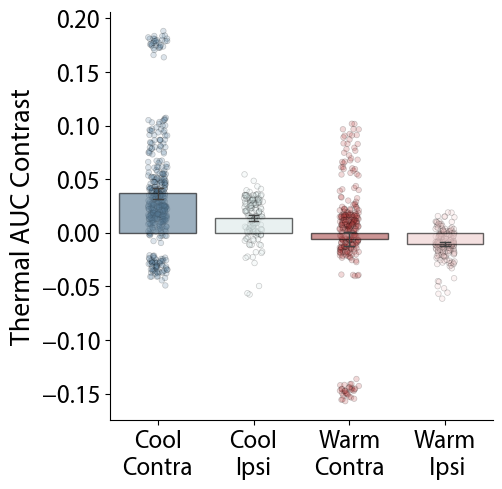

In [ ]:
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq')]
DATA=DATA[(DATA['Line']== 'ML')]

df1=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wcont')]
df1['condition'] = df1['Therm'] + '_' + df1['Side']
df2=DATA[(DATA['Therm'] == 'cool') & (DATA['Side'] == 'Wipsi')]
df2['condition'] = df2['Therm'] + '_' + df2['Side']
df3=DATA[(DATA['Therm'] == 'hot') & (DATA['Side'] == 'Wcont')]
df3['condition'] = df3['Therm'] + '_' + df3['Side']
df4=DATA[(DATA['Therm'] == 'hot') &(DATA['Side'] == 'Wipsi')]
df4['condition'] = df4['Therm'] + '_' + df4['Side']

df = pd.concat([df1, df2, df3, df4])



DF=df[['Date','condition','MeanAUCBas','MeanAUCStim','ContrastAUC']]
DF1=DF[(DF['condition'] == 'cool_Wcont') ]
DF1.drop(columns=['condition'], inplace=True)
DF1['condition']='cool_Wcont'

DF2=DF[(DF['condition'] == 'cool_Wipsi') ]
DF2.drop(columns=['condition'], inplace=True)
DF2['condition']='cool_Wipsi'

DF3=DF[(DF['condition'] == 'hot_Wcont') ]
DF3.drop(columns=['condition'], inplace=True)
DF3['condition']='hot_Wcont'

DF4=DF[(DF['condition'] == 'hot_Wipsi') ]
DF4.drop(columns=['condition'], inplace=True)
DF4['condition']='hot_Wipsi'

DF=pd.concat([DF1,DF2,DF3,DF4])

colors= {'cool_Wcont': '#507b9c', 'cool_Wipsi': '#D9EAEA', 
          'hot_Wcont': '#bb3f3f', 'hot_Wipsi': '#F2C7C7'}
border_colors = 'k'


fig,ax=plt.subplots(1,1, figsize=(5,5))

sns.barplot(ax=ax,x='condition', y='ContrastAUC',hue='condition' ,data=df, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6, edgecolor=border_colors)
ax.set_xticklabels(['Cool\nContra','Cool\nIpsi','Warm\nContra','Warm\n Ipsi'], multialignment='center')
ax.set_ylabel('Thermal AUC Contrast')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)


x,x2,x3,x4=0,1,2,3

sns.stripplot(
    ax=ax,
    x='condition',
    y='ContrastAUC',
    data=DF,
    jitter=True,                   # pour étaler les points horizontalement
    dodge=False,                   # ne pas séparer par hue
    marker='o',
    edgecolor='k',
    linewidth=0.5,
    size=4,
    palette=colors,
    alpha=0.2,
    zorder=0
)

ax.set_xlabel('')

plt.tight_layout()

titrefig='Fig_S8R_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)


In [38]:
dfstats=[]
dfstats.append(DF1["ContrastAUC"].values)
dfstats.append(DF2["ContrastAUC"].values)
dfstats.append(DF3["ContrastAUC"].values)
dfstats.append(DF4["ContrastAUC"].values)

np.savez_compressed(os.path.join(saving_dir, 'Data_Stats_fig_S8R.npz'), *dfstats)

#

<p align="center" style="color:orange; font-size: 2em;">FIGURE S9 : WT vs ML2 - Tactile & Thermal Stim </p>
<hr>

#

## Figure S9C

MannwhitneyuResult(statistic=82001.0, pvalue=0.2713134452028386)

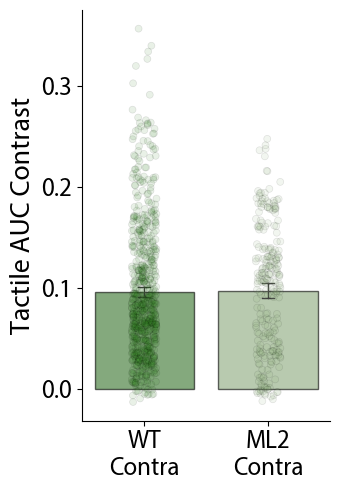

In [8]:
DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Tac') ]
DATA=DATA[(DATA['Side']== 'Wcont')]


df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(3.5,5))

border_colors = 'k'
colors = ['#2a7e19','#87ae73']

sns.barplot(x=df['Line'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, 
            alpha=0.6, edgecolor=border_colors,order=['WT', 'ML'])


sns.stripplot(x=df['Line'],y=df['ContrastAUC'],ax=ax,palette=colors,alpha=0.1,edgecolor=colorborder,linewidth=0.5,order=['WT', 'ML'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Tactile AUC Contrast')
ax.set_xticklabels(['WT\nContra','ML2\nContra'])
ax.set_xlabel('')

stat, p_value = mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])

plt.tight_layout()

titrefig='Fig_S9C_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])

#

## Figure S9H

2.4075685714701225e-14

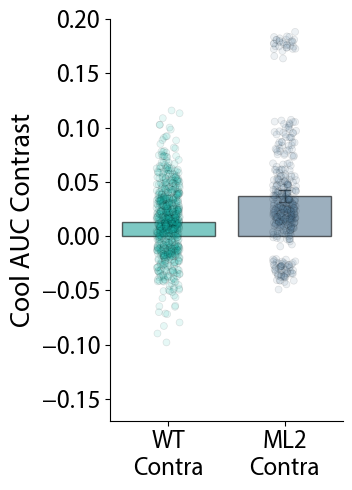

In [11]:
DATA=DATACleaned

DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Side']== 'Wcont')]
DATA=DATA[(DATA['Therm'] == 'cool') ]

df = pd.DataFrame(DATA)

fig,ax = plt.subplots(1,1, figsize=(3.5,5))

border_colors = 'k'
colors = ['#13bbaf', '#507b9c']


sns.barplot(x=df['Line'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6,
            edgecolor=border_colors,order=['WT','ML'])

sns.stripplot(x=df['Line'],y=df['ContrastAUC'],ax=ax,palette=colors,alpha=0.1,edgecolor=colorborder,linewidth=0.5,order=['WT','ML'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Cool AUC Contrast')
ax.set_xticklabels(['WT\nContra','ML2\nContra'])
ax.set_xlabel('')
ax.set_ylim(-0.17, 0.2)

stat, p_value = mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])


plt.tight_layout()

titrefig='Fig_S9H_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

p_value

#

## Figure S9I

0.46023917479697873

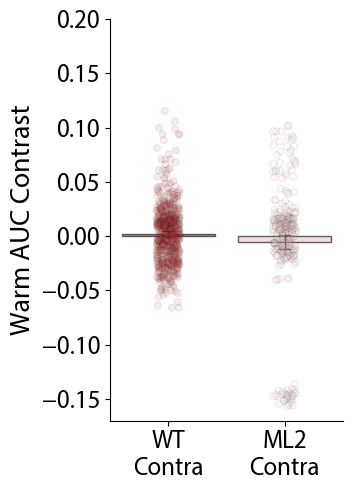

In [12]:
DATA=DATACleaned
DATA=DATA[(DATA['Stim'] == 'Thq') ]
DATA=DATA[(DATA['Side']== 'Wcont')]
DATA=DATA[(DATA['Therm'] == 'hot') ]


df = pd.DataFrame(DATA)
fig,ax = plt.subplots(1,1, figsize=(3.5,5))

border_colors = 'k'
colors = ['#bb3f3f', '#F2C7C7']

sns.barplot(x=df['Line'],y=df['ContrastAUC'],ax=ax, palette=colors, capsize=0.1, err_kws={'linewidth': 1}, alpha=0.6,
            edgecolor=border_colors,order=['WT','ML'])

sns.stripplot(x=df['Line'],y=df['ContrastAUC'],ax=ax,palette=colors,alpha=0.1,edgecolor=colorborder,linewidth=0.5,order=['WT','ML'])

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylabel('Warm AUC Contrast')
ax.set_xlabel('')
ax.set_xticklabels(['WT\nContra','ML2\nContra'])
ax.set_ylim(-0.17, 0.2)




stat, p_value = mannwhitneyu(df[df['Line']=='WT']['ContrastAUC'], df[df['Line']=='ML']['ContrastAUC'])

plt.tight_layout()

titrefig='Fig_S9I_LFP'

plt.savefig(os.path.join(saving_dir, titrefig+'.png'), format='png', dpi=300)
plt.savefig(os.path.join(saving_dir, titrefig+'.svg'), format='svg', dpi=300)

p_value